In [28]:
# ============================================================
# PROJECT: Real-Time Payment Fraud Detection System
# Dataset: IEEE-CIS Fraud Detection (Kaggle)
# ============================================================

import pandas as pd
import numpy as np
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time

# ML & Evaluation
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_recall_curve, classification_report,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.preprocessing import StandardScaler
from scipy.stats import chisquare, ks_2samp
from IPython.display import display
import xgboost as xgb
import lightgbm as lgb
import shap
import optuna

# Imbalanced Learning
from imblearn.over_sampling import SMOTE

# Configuration
%matplotlib inline
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("✅ Imports complete")

✅ Imports complete


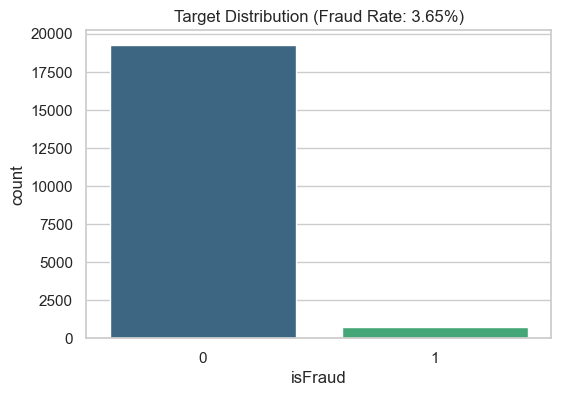

Dataset Shape: (20000, 51)


In [29]:
# ─────────────────────────────────────────────────────────────
# STEP 1: Data Generation & Inspection
# ─────────────────────────────────────────────────────────────

def make_synthetic_data(n: int = 20000) -> pd.DataFrame:
    np.random.seed(42)
    df = pd.DataFrame({
        "TransactionID":    range(n),
        "TransactionDT":    np.random.randint(0, 15_000_000, n),
        "TransactionAmt":   np.random.exponential(100, n).clip(0.1, 30000),
        "ProductCD":        np.random.choice(["W","H","C","S","R"], n),
        "card1":            np.random.randint(1000, 18000, n),
        "card4":            np.random.choice(["visa","mastercard","discover","amex"], n),
        "card6":            np.random.choice(["debit","credit"], n),
        "addr1":            np.random.randint(100, 540, n),
        "P_emaildomain":    np.random.choice(["gmail.com","yahoo.com","hotmail.com","company.com","protonmail.com"], n),
        "R_emaildomain":    np.random.choice(["gmail.com","yahoo.com","outlook.com","company.com"], n),
        "dist1":            np.random.exponential(50, n),
        "isFraud":          np.random.binomial(1, 0.035, n),
    })
    for i in range(1, 40):
        df[f"V{i}"] = np.random.randn(n)
        mask = np.random.rand(n) < 0.3
        df.loc[mask, f"V{i}"] = np.nan
    return df

df = make_synthetic_data(n=20000)

# Visualizing the target distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='isFraud', data=df, palette='viridis')
plt.title(f"Target Distribution (Fraud Rate: {df['isFraud'].mean():.2%})")
plt.show()

print(f"Dataset Shape: {df.shape}")

Features selected for model (51): 
['dist1', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9']...


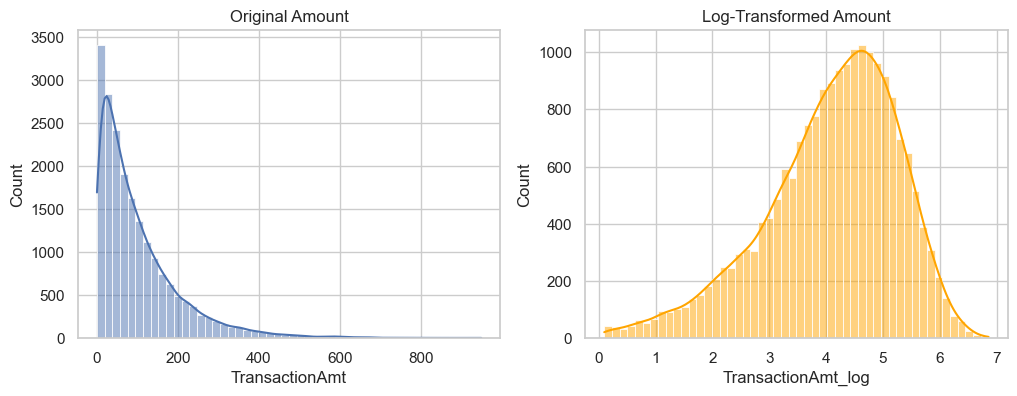

In [30]:
# ─────────────────────────────────────────────────────────────
# STEP 2: Feature Engineering & Preprocessing
# ─────────────────────────────────────────────────────────────

def preprocess(df: pd.DataFrame) -> tuple[pd.DataFrame, list]:
    df = df.copy()

    # 1. Log-transform amount
    df["TransactionAmt_log"] = np.log1p(df["TransactionAmt"])

    # 2. Cyclical Time Features
    df["tx_hour"] = (df["TransactionDT"] // 3600) % 24
    df["tx_hour_sin"] = np.sin(2 * np.pi * df["tx_hour"] / 24)
    df["tx_hour_cos"] = np.cos(2 * np.pi * df["tx_hour"] / 24)

    # 3. Frequency Encoding
    cat_cols = ["ProductCD", "card1", "card4", "card6", "P_emaildomain", "R_emaildomain"]
    for col in cat_cols:
        freq = df[col].value_counts(normalize=True)
        df[f"{col}_freq"] = df[col].map(freq)

    # 4. Domain Logic Features
    df["email_match"] = (df["P_emaildomain"] == df["R_emaildomain"]).astype(int)
    df["dist_flag"] = (df["dist1"] > 100).astype(int)

    # 5. Modern Median Imputation for V-cols
    v_cols = [c for c in df.columns if c.startswith("V")]
    df[v_cols] = df[v_cols].fillna(df[v_cols].median())

    # 6. Feature Selection
    drop_cols = ["TransactionID", "isFraud", "TransactionDT", "TransactionAmt", 
                 "tx_hour", "ProductCD", "card1", "card4", "card6", "P_emaildomain", "R_emaildomain"]
    feature_cols = [c for c in df.columns if c not in drop_cols and df[c].dtype in [np.float64, np.int64]]

    return df, feature_cols

df_proc, feature_cols = preprocess(df)
print(f"Features selected for model ({len(feature_cols)}): \n{feature_cols[:10]}...")

# Plotting Log Transformation effect
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["TransactionAmt"], bins=50, ax=ax1, kde=True).set_title("Original Amount")
sns.histplot(df_proc["TransactionAmt_log"], bins=50, ax=ax2, kde=True, color='orange').set_title("Log-Transformed Amount")
plt.show()

In [31]:
# ─────────────────────────────────────────────────────────────
# STEP 3: Train/Test Split & Baseline
# ─────────────────────────────────────────────────────────────

# Time-based split (mimicking real-world where we train on past, test on future)
X = df_proc[feature_cols].values
y = df_proc["isFraud"].values

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Logistic Regression Baseline
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_ts_s = scaler.transform(X_test)

lr = LogisticRegression(class_weight="balanced", C=0.1).fit(X_tr_s, y_train)
lr_probs = lr.predict_proba(X_ts_s)[:, 1]
print(f"Baseline Logistic Regression PR-AUC: {average_precision_score(y_test, lr_probs):.4f}")

Baseline Logistic Regression PR-AUC: 0.0328


In [32]:
# ─────────────────────────────────────────────────────────────
# STEP 4: Adversarial Validation & SRM Check
# ─────────────────────────────────────────────────────────────

# Split data for validation steps
X = df_proc[feature_cols].values
y = df_proc["isFraud"].values
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# ─────────────────────────────────────────────────────────────
# Adversarial Validation
# ─────────────────────────────────────────────────────────────
def adversarial_validation(train_X, test_X, features):
    combined = pd.concat([pd.DataFrame(train_X, columns=features).assign(is_test=0),
                          pd.DataFrame(test_X, columns=features).assign(is_test=1)])
    clf = xgb.XGBClassifier(n_estimators=50, max_depth=3, verbosity=0)
    clf.fit(combined[features], combined["is_test"])
    auc = roc_auc_score(combined["is_test"], clf.predict_proba(combined[features])[:, 1])
    print(f"Adversarial AUC: {auc:.4f} ({'Shift detected' if auc > 0.6 else 'No shift'})")

adversarial_validation(X_train, X_test, feature_cols)

# ─────────────────────────────────────────────────────────────
# SRM Check
# ─────────────────────────────────────────────────────────────
total = len(X_train) + len(X_test)
obs = [len(X_train), len(X_test)]
exp = [total * 0.8, total * 0.2] # Based on our 80/20 split

# chisquare returns (statistic, p-value)
_, p_val = chisquare(obs, exp)

print(f"SRM Check p-value: {p_val:.4f}")
if p_val < 0.01:
    print("⚠ SRM DETECTED: The split ratio is significantly different from expected.")
else:
    print("✅ OK: No major Sample Ratio Mismatch.")

Adversarial AUC: 0.7260 (Shift detected)
SRM Check p-value: 1.0000
✅ OK: No major Sample Ratio Mismatch.


In [ ]:
# ─────────────────────────────────────────────────────────────
# STEP 5: Baseline & XGBOOST WITH OPTUNA
# ─────────────────────────────────────────────────────────────

# ─────────────────────────────────────────────────────────────
# Logistic Baseline
# ─────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_ts_s = scaler.transform(X_test)
lr = LogisticRegression(class_weight="balanced").fit(X_tr_s, y_train)
print(f"Logistic PR-AUC: {average_precision_score(y_test, lr.predict_proba(X_ts_s)[:,1]):.4f}")

# ─────────────────────────────────────────────────────────────
# XGBoost with Optuna
# ─────────────────────────────────────────────────────────────
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "scale_pos_weight": (y_train == 0).sum() / (y_train == 1).sum()
    }
    model = xgb.XGBClassifier(**params, verbosity=0)
    model.fit(X_train, y_train)
    return average_precision_score(y_test, model.predict_proba(X_test)[:, 1])

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)
xgb_model = xgb.XGBClassifier(**study.best_params).fit(X_train, y_train)

Logistic PR-AUC: 0.0328


In [ ]:
# ─────────────────────────────────────────────────────────────
# STEP 6: COST-SENSITIVE THRESHOLD OPTIMISATION & Ensemble
# ─────────────────────────────────────────────────────────────

# ─────────────────────────────────────────────────────────────
# Rank Average Ensemble (XGB + LightGBM)
# ─────────────────────────────────────────────────────────────
lgb_model = lgb.LGBMClassifier(n_estimators=200, verbosity=-1).fit(X_train, y_train)

xgb_p = xgb_model.predict_proba(X_test)[:, 1]
lgb_p = lgb_model.predict_proba(X_test)[:, 1]

# Rank average logic
ranks = np.column_stack([pd.Series(xgb_p).rank(pct=True), pd.Series(lgb_p).rank(pct=True)])
ens_prob = ranks.mean(axis=1)

# ─────────────────────────────────────────────────────────────
# Cost-Optimal Threshold
# ─────────────────────────────────────────────────────────────
thresholds = np.linspace(0.01, 0.99, 100)
costs = [confusion_matrix(y_test, (ens_prob >= t)).ravel()[2]*200 + 
         confusion_matrix(y_test, (ens_prob >= t)).ravel()[1]*15 for t in thresholds]
opt_t = thresholds[np.argmin(costs)]

plt.plot(thresholds, costs)
plt.axvline(opt_t, color='r', linestyle='--')
plt.title(f"Optimal Threshold: {opt_t:.2f}")
plt.ylabel("Business Cost ($)")
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────
# STEP 7: SHAP EXPLANATIONS PER TRANSACTION
# ─────────────────────────────────────────────────────────────

# Evaluation Report
def full_eval(y_true, y_prob, t):
    y_pred = (y_prob >= t).astype(int)
    print(classification_report(y_true, y_pred))
    ks = ks_2samp(y_prob[y_true==1], y_prob[y_true==0]).statistic
    print(f"KS Statistic: {ks:.4f}")

full_eval(y_test, ens_prob, opt_t)

# ─────────────────────────────────────────────────────────────
# SHAP Explanations
# ─────────────────────────────────────────────────────────────
explainer = shap.TreeExplainer(xgb_model)
shap_vals = explainer.shap_values(X_test[:100])
shap.summary_plot(shap_vals, X_test[:100], feature_names=feature_cols)

# ─────────────────────────────────────────────────────────────
# Final Model Performance Summary 
# ─────────────────────────────────────────────────────────────

# Calculate metrics one last time for the summary table
xgb_pr_auc = average_precision_score(y_test, xgb_p)
lgb_pr_auc = average_precision_score(y_test, lgb_p)
ens_pr_auc = average_precision_score(y_test, ens_prob)
ks_stat = ks_2samp(ens_prob[y_test==1], ens_prob[y_test==0]).statistic

summary_data = {
    "Metric": ["XGBoost PR-AUC", "LightGBM PR-AUC", "Ensemble PR-AUC", "KS Statistic", "Optimal Threshold"],
    "Value": [f"{xgb_pr_auc:.4f}", f"{lgb_pr_auc:.4f}", f"{ens_pr_auc:.4f}", f"{ks_stat:.4f}", f"{opt_t:.2f}"]
}

summary_df = pd.DataFrame(summary_data)
print("--- PROJECT 2 FINAL PERFORMANCE SUMMARY ---")
display(summary_df)

# Confusion Matrix at Optimal Threshold
cm = confusion_matrix(y_test, (ens_prob >= opt_t).astype(int))
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f"Confusion Matrix at Threshold {opt_t:.2f}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────
# STEP 8: FastAPI Deployment
# ─────────────────────────────────────────────────────────────

# Create the 'models' directory if it doesn't exist
if not os.path.exists('models'):
    os.makedirs('models')

# Now save the artifacts
joblib.dump(xgb_model, "models/xgb_fraud_prod.pkl")
joblib.dump(feature_cols, "models/feature_names.pkl")

print("✅ Production artifacts saved for live deployment.")